In [3]:
# Cell 1 — setup: load combined MADAR TSV + checkpoints

import pandas as pd
import torch
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM

MADAR_FILE = "../data/eval/madar_combined.tsv"

CHECKPOINTS = [
    "outputs/reddit-v1/log/model_190000.pt",
    # "outputs/20260602_174508/log/model_180000.pt",
]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

df = pd.read_csv(MADAR_FILE, sep="\t")

TEXT_COLS = [c for c in df.columns if c != "sentID.BTEC"]

df = df.dropna(subset=TEXT_COLS, how="all").reset_index(drop=True)

print(df.shape)
print(TEXT_COLS)


(12000, 27)
['ALE', 'ALX', 'ALG', 'AMM', 'ASW', 'BAG', 'BAS', 'BEI', 'BEN', 'CAI', 'DAM', 'DOH', 'FES', 'JED', 'JER', 'KHA', 'MSA', 'MOS', 'MUS', 'RAB', 'RIY', 'SAL', 'SAN', 'SFX', 'TRI', 'TUN']


In [3]:
# Cell 1 — load log file

import pandas as pd
import matplotlib.pyplot as plt

LOG_FILE = "outputs/reddit-v1/log/log.txt"

records = []

with open(LOG_FILE, "r") as f:
    for line in f:
        parts = line.strip().split()

        if len(parts) != 3:
            continue

        step = int(parts[0])
        split = parts[1]
        loss = float(parts[2])

        records.append({
            "step": step,
            "split": split,
            "loss": loss
        })

df = pd.DataFrame(records)

print(df.head())
print(df["split"].value_counts())

   step  split       loss
0     0    val  11.228000
1     0  train  11.247301
2     1  train  11.192103
3     2  train  11.104416
4     3  train  10.979387
split
train    363000
val          74
Name: count, dtype: int64


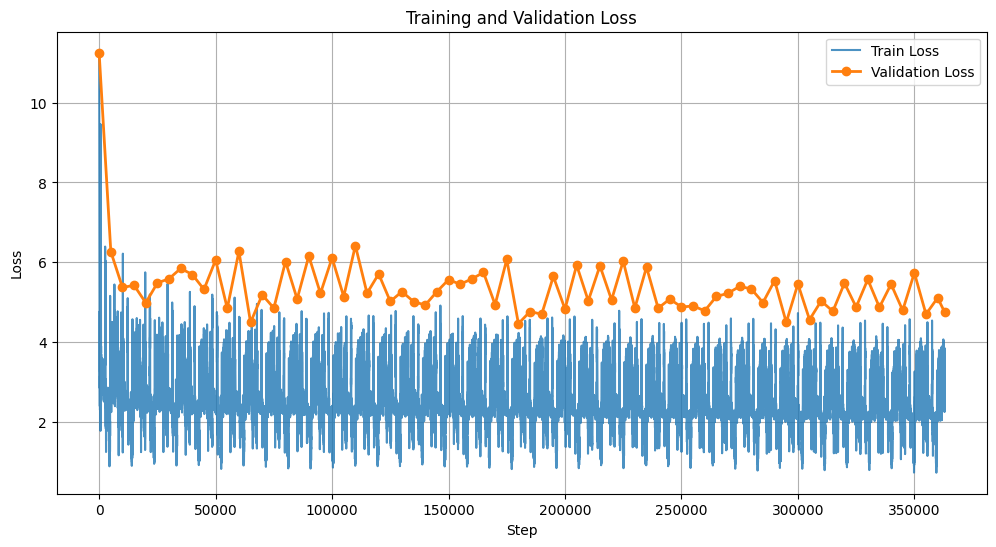

In [2]:
# Cell 2 — plot train and validation loss

plt.figure(figsize=(12,6))

train_df = df[df["split"] == "train"]
val_df = df[df["split"] == "val"]

plt.plot(
    train_df["step"],
    train_df["loss"],
    label="Train Loss",
    alpha=0.8
)

plt.plot(
    val_df["step"],
    val_df["loss"],
    marker="o",
    linewidth=2,
    label="Validation Loss"
)

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [4]:
# Cell 0 — custom model loader for your .pt checkpoints

import torch
import torch.nn.functional as F
from pathlib import Path
from transformers import AutoTokenizer
from models.gpt import GPT, GPTConfig

# import or paste your GPTConfig and GPT classes above this cell
# from train_gpt2 import GPT, GPTConfig  # only if importing does NOT start training

TOKENIZER_NAME = "riotu-lab/Aranizer-PBE-64k"

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def load_custom_gpt(pt_path):
    ckpt = torch.load(pt_path, map_location="cpu", weights_only=False)

    config = ckpt.get("config", GPTConfig())

    model = GPT(config)


    state_dict = ckpt["model"]

    # just in case saved from DDP/compiled model
    state_dict = {
        k.replace("module.", "").replace("_orig_mod.", ""): v
        for k, v in state_dict.items()
    }

    model.load_state_dict(state_dict, strict=True)
    model.to(DEVICE)
    model.eval()
    # print where model is loaded on
    return model

ModuleNotFoundError: No module named 'models'

In [ ]:
# Cell 2 — eval 1: perplexity per dialect/city column

import math
@torch.no_grad()
def compute_ppl_custom(model, tokenizer, texts, max_length=512):
    total_loss = 0.0
    total_tokens = 0

    for text in tqdm(texts, leave=False):
        ids = tokenizer.encode(str(text))[:max_length + 1]

        if len(ids) < 2:
            continue

        x = torch.tensor(ids[:-1], dtype=torch.long, device=DEVICE).unsqueeze(0)
        y = torch.tensor(ids[1:], dtype=torch.long, device=DEVICE).unsqueeze(0)

        logits, loss = model(x, y)

        n_tokens = y.numel()
        total_loss += loss.item() * n_tokens
        total_tokens += n_tokens

    return math.exp(total_loss / total_tokens)

ppl_results = []

for ckpt in CHECKPOINTS:
    print(f"\nLoading {ckpt}")

    # NEW
    model = load_custom_gpt(ckpt)

    for col in TEXT_COLS:
        texts = df[col].dropna().astype(str).head(1000).tolist()
        ppl = compute_ppl_custom(model, tokenizer, texts)

        ppl_results.append({
            "checkpoint": ckpt,
            "dialect": col,
            "perplexity": ppl
        })

        print(ckpt, col, ppl)

    del model
    torch.cuda.empty_cache()

ppl_results = pd.DataFrame(ppl_results)
ppl_results


Loading outputs/reddit-v1/log/model_190000.pt


NameError: name 'embed_texts_custom' is not defined

In [12]:
import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity

@torch.no_grad()
def embed_texts_custom(
    model,
    tokenizer,
    texts,
    batch_size=32,
    max_length=128,
):
    vectors = []

    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i + batch_size]

        ids_list = []

        for text in batch:
            ids = tokenizer.encode(str(text))[:max_length]

            if len(ids) == 0:
                ids = [tokenizer.eos_token_id]

            ids_list.append(torch.tensor(ids))

        x = torch.nn.utils.rnn.pad_sequence(
            ids_list,
            batch_first=True,
            padding_value=0
        ).to(DEVICE)

        B, T = x.shape

        tok_emb = model.transformer.wte(x)

        pos = torch.arange(
            0,
            T,
            device=DEVICE
        ).unsqueeze(0)

        pos_emb = model.transformer.wpe(pos)

        h = tok_emb + pos_emb

        for block in model.transformer.h:
            h = block(h)

        h = model.transformer.ln_f(h)

        mask = (x != 0).float().unsqueeze(-1)

        pooled = (h * mask).sum(1) / mask.sum(1).clamp(min=1)

        pooled = F.normalize(pooled, dim=1)

        vectors.append(pooled.cpu())

    return torch.cat(vectors).numpy()

In [ ]:
SOURCE_COL = "MSA"
TARGET_COL = "ALX"

eval_df = (
    df[[SOURCE_COL, TARGET_COL]]
    .dropna()
    .head(1000)
)

src_texts = eval_df[SOURCE_COL].astype(str).tolist()
tgt_texts = eval_df[TARGET_COL].astype(str).tolist()

model = load_custom_gpt(CHECKPOINTS[0])

src_emb = embed_texts_custom(
    model,
    tokenizer,
    src_texts
)

tgt_emb = embed_texts_custom(
    model,
    tokenizer,
    tgt_texts
)

sim_matrix = cosine_similarity(
    src_emb,
    tgt_emb
)

ranks = []

for i in range(len(sim_matrix)):
    ranking = np.argsort(-sim_matrix[i])

    rank = np.where(ranking == i)[0][0] + 1
    ranks.append(rank)

ranks = np.array(ranks)

recall_at_1 = np.mean(ranks <= 1)
recall_at_5 = np.mean(ranks <= 5)
recall_at_10 = np.mean(ranks <= 10)
mrr = np.mean(1.0 / ranks)

print(f"Recall@1  = {recall_at_1:.4f}")
print(f"Recall@5  = {recall_at_5:.4f}")
print(f"Recall@10 = {recall_at_10:.4f}")
print(f"MRR       = {mrr:.4f}")

  0%|          | 0/32 [00:00<?, ?it/s]


AttributeError: 'RobertaForMaskedLM' object has no attribute 'transformer'

## eval hf models

In [22]:
import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm

@torch.no_grad()
def embed_texts_hf(
    model,
    tokenizer,
    texts,
    batch_size=32,
    max_length=128,
):
    model.eval()

    vectors = []

    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i + batch_size]

        enc = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length,
        )

        enc = {k: v.to(DEVICE) for k, v in enc.items()}

        outputs = model(
            **enc,
            output_hidden_states=False,
            return_dict=True,
        )

        h = outputs.last_hidden_state

        mask = enc["attention_mask"].unsqueeze(-1)

        pooled = (h * mask).sum(1) / mask.sum(1).clamp(min=1)

        pooled = F.normalize(pooled, dim=1)

        vectors.append(pooled.cpu())

    return torch.cat(vectors).numpy()

In [27]:
from sklearn.metrics.pairwise import cosine_similarity

SOURCE_COL = "MSA"
TARGET_COL = "ALX"

eval_df = (
    df[[SOURCE_COL, TARGET_COL]]
    .dropna()
    .head(1000)
)

src_texts = eval_df[SOURCE_COL].astype(str).tolist()
tgt_texts = eval_df[TARGET_COL].astype(str).tolist()

from transformers import AutoTokenizer, AutoModel

# MODEL_NAME = "rahbi/alclam-base-v2"
MODEL_NAME = "UBC-NLP/MARBERTv2"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModel.from_pretrained(
    MODEL_NAME
).to(DEVICE)

model.eval()

src_emb = embed_texts_hf(
    model,
    tokenizer,
    src_texts
)

tgt_emb = embed_texts_hf(
    model,
    tokenizer,
    tgt_texts
)

sim_matrix = cosine_similarity(
    src_emb,
    tgt_emb
)

ranks = []

for i in range(len(sim_matrix)):
    ranking = np.argsort(-sim_matrix[i])

    rank = np.where(ranking == i)[0][0] + 1
    ranks.append(rank)

ranks = np.array(ranks)

print("Recall@1  =", np.mean(ranks <= 1))
print("Recall@5  =", np.mean(ranks <= 5))
print("Recall@10 =", np.mean(ranks <= 10))
print("MRR       =", np.mean(1.0 / ranks))

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 25566.41it/s]
[transformers] BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 32/32 [00:09<00:00,  3.27it/s]

Recall@1  = 0.467
Recall@5  = 0.591
Recall@10 = 0.645
MRR       = 0.5251863129817231
